In [1]:
using CSV, DataFrames, Dates, PDMats, SpecialFunctions
using Distributions, Extremes, IDFCurves, QuantileMatching, Gadfly
using Test
using LinearAlgebra, MambaLite, Random
using Statistics

Le cas classique pour étudier des événements extrêmes est de modéliser les données par une distribution GEV à 3 paramètres pour une durée d'accumulation. Les distributions sont donc considérées indépendantes pour chaque durée. Une optimisation possible pour la GEV est de considérer la relation d'échelle entre les durées pour augmenter la précision des estimations. Cette distribution est dite dGEV ou general scaling et possède 5 paramètres (μ₀, σ₀, ξ , α, δ). Par cette méthode, plutôt que d'avoir 3 paramètres pour chaque durée (disons 3x5=15), on réduit le nombre à seulement 5 paramètres pour l'ensemble des durées.

Ainsi, je commence d'abord par modéliser la série de maxima annuel historiques de l'aéroport de Montréal par une dGEV stationnaire. Je trace ensuite le QQ-plot pour la durée de 24h. 

In [2]:
idf_mtl_trudeau = CSV.read("C:\\Users\\CM\\Polytechnique\\IDFCurves.jl\\data\\702S006-2.csv", DataFrame)
idf_mtl_trudeau = idf_mtl_trudeau[idf_mtl_trudeau.Year .>= 1955, :]
first(idf_mtl_trudeau, 5)

durations = [1/12, 1/6, 1/4, 1/2, 1, 2, 6, 12, 24]
tags = names(idf_mtl_trudeau)[2:10]
duration_dict = Dict(zip(tags, durations))
data = IDFdata(idf_mtl_trudeau, "Year", duration_dict)

pd = DependentScalingModel{GeneralScaling, UncorrelatedStructure, IdentityCopula}
f_dist = IDFCurves.fit_mle(pd, data, 1,  [20, 5, .04, .76, .07])

DependentScalingModel{GeneralScaling{Float64, Float64}, UncorrelatedStructure, IdentityCopula}(GeneralScaling{Float64, Float64}(d₀ = 1.0, μ₀ = 20.1742, σ₀ = 5.6374, ξ = 0.0444, α = 0.7708, δ = 0.0826)
, UncorrelatedStructure())

64×4 DataFrame
 Row │ Empirical  Model    Inf      Sup     
     │ Float64    Float64  Float64  Float64 
─────┼──────────────────────────────────────
   1 │    1.3125  1.13212  1.0492   1.21503
   2 │    1.4292  1.22041  1.13952  1.30129
   3 │    1.4417  1.28103  1.20064  1.36142
   4 │    1.4583  1.32933  1.24887  1.4098
   5 │    1.4708  1.37054  1.28971  1.45137
   6 │    1.4917  1.40709  1.32573  1.48845
   7 │    1.5083  1.44034  1.35834  1.52234
   8 │    1.5292  1.47115  1.38844  1.55387
   9 │    1.5375  1.50008  1.4166   1.58357
  10 │    1.5417  1.52753  1.44323  1.61183
  11 │    1.5667  1.55379  1.46865  1.63893
  12 │    1.5833  1.57908  1.49306  1.66509
  13 │    1.6     1.60357  1.51667  1.69047
  14 │    1.6     1.62741  1.53959  1.71523
  15 │    1.6083  1.65071  1.56196  1.73946
  16 │    1.6208  1.67357  1.58388  1.76326
  17 │    1.6292  1.69606  1.60541  1.78671
  18 │    1.6583  1.71826  1.62663  1.8099
  19 │    1.6667  1.74024  1.64762  1.83286
  20 │    1.6833

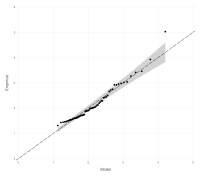

In [3]:
set_default_plot_size(20cm, 18cm)
p1_24h = IDFCurves.qqplotci(f_dist, data, 24)

Ensuite, je conserve l'estimation du paramètre delta pour réutiliser celle-ci plus tard avec les données simulées. Je trace les courbes IDF en prenant soin de calculer les intervalles de confiance en utilisant les distributions marginales produites par la dGEV.

In [4]:
delta = offset(getmarginalmodel(f_dist))

0.08259411257260287

┌ Warning: The following aesthetics are mapped, but not used by any geometry:
│ shape
└ @ Gadfly C:\Users\CM\.julia\packages\Gadfly\OQ068\src\Gadfly.jl:503
┌ Warning: The following aesthetics are mapped, but not used by any geometry:
│ shape
└ @ Gadfly C:\Users\CM\.julia\packages\Gadfly\OQ068\src\Gadfly.jl:503


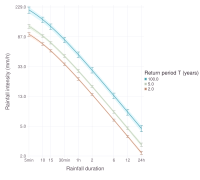

In [5]:
set_default_plot_size(20cm, 18cm)
plotIDFCurves(f_dist, data, show_confidence_intervals=true, ribbon=true, dgev_return_levels=true, T_values=[2,5,100])

Je refais le même processus, mais cette fois-ci avec les données simulées ClimEx pour l'aéroport de Montréal: modélisation de la série de maxima annuel simulées par une dGEV stationnaire. 

Je dois d'abord aggréger les données pour les différents durées d'accumulation (1h, 2h, 6h, 12h et 24h). Les durées infra-horaires ne sont pas disponibles. Ensuite, il est commun de faire une correction des biais par méthode XCDF-t pour corriger les X.

Je modélise ensuite la dGEV et trace le QQplot et les courbes IDF pour le modèle stationnaire.

In [6]:
# CLIMEX, composé de 50 membres, mais spécifiquemenet au point latitude, longitude Montreal.
"""
    annualmax(durations::Vector{<:Real}, all::Bool = true, writeOut::Bool = false)

    Annual maximum of array data.
    Hourly time series. Extract the highest value for year i.
"""
function annualmax(durations::Vector{<:Real}, all::Bool = true, writeOut::Bool = false)
    folder_path = "data/climEx_hrs"
    csv_dict = Dict{String, DataFrame}()
    csv_files = filter(x -> occursin(".csv", x), readdir(folder_path))

    for file in csv_files
        # Initialize an empty DataFrame for storing results
        final_df = DataFrame()

        for duration in durations
            file_path = joinpath(folder_path, file)
            climex_df = CSV.read(file_path, DataFrame)

            df_daily_agg = combine(groupby(transform(climex_df, :Date => ByRow(x->round(x, Dates.Hour(duration), RoundDown)) => :Grouped_Period, renamecols=false),  :Grouped_Period), :Pluie=>sum=>:Pluie)
            df_daily_agg = transform(df_daily_agg, :Grouped_Period => ByRow(x -> Dates.year(x)) => :Year, :Grouped_Period => ByRow(x -> Dates.month(x)) => :Month, copycols=false)
            numYears = unique(df_daily_agg[!,:Year])

            # Filter for months May (5) to October (10)
            df_daily_agg = filter(row -> row.Month >= 5 && row.Month <= 10, df_daily_agg)

            annual_maxima = zeros(length(numYears))
            for i in 1:(length(numYears))
                idx = searchsortedfirst(df_daily_agg[!,:Year], numYears[i]):searchsortedlast(df_daily_agg[!,:Year], numYears[i])
                annual_maxima[i] = Statistics.maximum(df_daily_agg[idx,:Pluie])
            end

            maxima_col = string("Maxima $(duration)h")
            df_annual_maxima = DataFrame(Year = numYears, Maxima = annual_maxima)
            df_annual_maxima = rename(df_annual_maxima, :Maxima => maxima_col)
            df_annual_maxima[!, maxima_col] = Float64.(df_annual_maxima[!, maxima_col]) ./ duration

            if writeOut
                CSV.write(string("$(duration)h.csv"), df_annual_maxima)
            end

            # Combine with final DataFrame
            if ncol(final_df) == 0
                final_df = df_annual_maxima
            else
                final_df = outerjoin(final_df, df_annual_maxima, on=:Year, makeunique=true)
            end
            clean_df = dropmissing(final_df)
            csv_dict[file] = clean_df

        end

        if !all
            break
        end
    end

    return csv_dict
end 

df_annual_maxima = annualmax([1,2,6,12,24], false)
df_climex = df_annual_maxima["kda.csv"]

Row,Year,Maxima 1h,Maxima 2h,Maxima 6h,Maxima 12h,Maxima 24h
,Int64,Float64,Float64,Float64,Float64,Float64
1,1955,14.214,10.1337,4.29223,2.18136,1.32693
2,1956,15.17,9.3672,4.10434,2.14255,1.75852
3,1957,64.6999,47.1591,17.1832,8.59173,4.29587
4,1958,40.7226,27.7022,9.53986,4.77297,2.43328
5,1959,21.1702,11.2942,4.24236,3.7224,2.34809
6,1960,19.8433,15.9374,7.06427,3.54471,1.79628
7,1961,26.574,17.351,5.98105,3.52962,1.76481
8,1962,30.3827,15.1914,6.78306,3.7516,2.04078
9,1963,13.5234,11.5247,5.91036,4.73592,2.36799


In [7]:
# idf_mtl_trudeau_1955_2021 = idf_mtl_trudeau[idf_mtl_trudeau.Year .>= 1955, :]
# df_1955_2021 = df_climex[2021 .>= df_climex.Year, :]
# df_2022_2099 = df_climex[df_climex.Year .>= 2022, :]

# function generate_pqm(obs_location_column, location_column)
#     x_o = idf_mtl_trudeau_1955_2021[!,obs_location_column]
#     x_h = df_1955_2021[!,location_column]
#     x_p = df_2022_2099[!,location_column]

#     x_o = filter(val -> val >0, x_o)
#     x_h = filter(val -> val >0, x_h)
#     x_p = filter(val -> val >0, x_p)

#     fm_24h_obs = gevfit(idf_mtl_trudeau_1955_2021, obs_location_column)
#     fm_24h_sim = gevfit(df_1955_2021, location_column)
#     fm_24h_proj = gevfit(df_2022_2099, location_column)

#     f_obs = GeneralizedExtremeValue(fm_24h_obs.θ̂[1], exp(fm_24h_obs.θ̂[2]), fm_24h_obs.θ̂[3])
#     f_sim = GeneralizedExtremeValue(fm_24h_sim.θ̂[1], exp(fm_24h_sim.θ̂[2]), fm_24h_sim.θ̂[3])
#     f_proj = GeneralizedExtremeValue(fm_24h_proj.θ̂[1], exp(fm_24h_proj.θ̂[2]), fm_24h_proj.θ̂[3])

#     qmm = ParametricQuantileMatchingModel(f_obs, f_sim, f_sim) 
#     x̃_h = match(qmm, x_h)

#     qmm = ParametricQuantileMatchingModel(f_obs, f_sim, f_proj)
#     x̃_p = match(qmm, x_p)

#     x̃ = append!(x̃_h, x̃_p)
#     pqm_column = Symbol(string(obs_location_column),"-PQM")

#     df_climex[!, Symbol(pqm_column)] = x̃

#     set_default_plot_size(24cm, 18cm)
#     p = Gadfly.plot(layer(df_climex, x=:Year, y=string(location_column), Geom.line),
#         layer(df_climex, x=:Year, y=string(pqm_column), Geom.line, Theme(default_color=colorant"red")),
#         Coord.cartesian(xmin=1955, xmax=2099), Guide.xticks(ticks=1955:10:2100),
#         Guide.ylabel("Rainfall Intensity (mm/h)"),
#         Guide.xlabel("Year"),
#         Guide.title(string("XCDF-t Bias Correction of ClimEx ", obs_location_column, " Rainfall Intensity at Montreal Airport")),
#         Guide.manual_color_key("BC method", ["Raw", "Stationary"], ["blue", "red"]))

#     display(p)
#     # draw(PNG("/Users/camarois/Documents/maitrise/JuliaExtremes/maitrise/pictures/bcind/xcdf-t_1955_2099.png", 24cm, 18cm), p)
    
#     return df_climex
# end

# generate_pqm(Symbol("1h"), Symbol("Maxima 1h"))
# generate_pqm(Symbol("2h"), Symbol("Maxima 2h"))
# generate_pqm(Symbol("6h"), Symbol("Maxima 6h"))
# generate_pqm(Symbol("12h"), Symbol("Maxima 12h"))
# generate_pqm(Symbol("24h"), Symbol("Maxima 24h"))

# df_climex

In [8]:
durations = [1, 2, 6, 12, 24]
tags = names(df_climex)[2:6]
duration_dict = Dict(zip(tags, durations))

df_climex = df_climex[df_climex.Year .>= 1955, :]
climex_data = IDFdata(df_climex, "Year", duration_dict)

IDFdata
  Maxima 1h: Vector{Float64}[145]
  Maxima 2h: Vector{Float64}[145]
  Maxima 6h: Vector{Float64}[145]
  Maxima 12h: Vector{Float64}[145]
  Maxima 24h: Vector{Float64}[145]


Le pas de temps horaire est le pas le plus granulaire disponible pour les données simulées. Je commence par modéliser la dGEV en effectuant une optimisation par contrainte sur le paramètre delta en reprenant la valeur obtenue lors de l'analyse de la dGEV historique ce qui aidera à conserver une échelle similaire entre les durées d'accumulation.

DependentScalingModel{GeneralScaling{Real, Real}, UncorrelatedStructure, IdentityCopula}(GeneralScaling{Real, Real}(d₀ = 1, μ₀ = 19.8774, σ₀ = 6.9214, ξ = 0.1051, α = 0.7493, δ = 0.0826)
, UncorrelatedStructure())
3498.5695326494047
145×4 DataFrame
 Row │ Empirical  Model     Inf       Sup     
     │ Float64    Float64   Float64   Float64 
─────┼────────────────────────────────────────
   1 │  0.956864  0.944002  0.860197  1.02781
   2 │  0.967778  1.03034   0.95068   1.11
   3 │  1.03303   1.08833   1.01062   1.16604
   4 │  1.05568   1.13369   1.05705   1.21032
   5 │  1.06646   1.17172   1.0957    1.24774
   6 │  1.08572   1.20492   1.12921   1.28063
   7 │  1.20046   1.23467   1.15909   1.31025
   8 │  1.32693   1.26182   1.18622   1.33742
   9 │  1.33824   1.28694   1.21122   1.36266
  10 │  1.34488   1.31042   1.23451   1.38634
  11 │  1.34844   1.33257   1.2564    1.40873
  12 │  1.36475   1.35358   1.27711   1.43006
  13 │  1.37482   1.37364   1.29682   1.45046
  14 │  1.39035

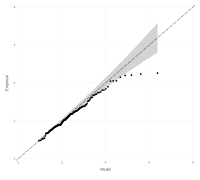

In [9]:
# Modèle stationnaire
constrainedvalues = [nothing, nothing, nothing, nothing, log(delta)]

pd = GeneralScaling(1.0, 23, 5.0, -.025, .835, .001)   
Σ = UncorrelatedStructure()
C = IdentityCopula

dsm = DependentScalingModel(pd, Σ, C) 
gaussian_fd = IDFCurves.fit_mle(dsm, climex_data, 1, [23, 5.0, -.025, .835, .001], constrainedvalues)

println(gaussian_fd)
println(IDFCurves.bic(gaussian_fd, climex_data))

p1_24h = IDFCurves.qqplotci(gaussian_fd, climex_data, 24)

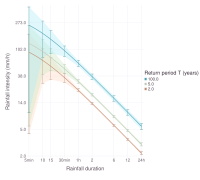

┌ Warning: The following aesthetics are mapped, but not used by any geometry:
│ shape
└ @ Gadfly C:\Users\CM\.julia\packages\Gadfly\OQ068\src\Gadfly.jl:503
┌ Warning: The following aesthetics are mapped, but not used by any geometry:
│ shape
└ @ Gadfly C:\Users\CM\.julia\packages\Gadfly\OQ068\src\Gadfly.jl:503


In [10]:
set_default_plot_size(20cm, 18cm)
plotIDFCurves(gaussian_fd, climex_data, show_confidence_intervals=true, ribbon=true, dgev_return_levels=true, T_values=[2,5,100])

Pour les données simulées, puisque les valeurs infra-horaires ne sont pas disponibles, elles dépendent entièrement de la relation d'échelle qui est déterminée lors de l'optimisation de la dGEV. Cela explique pourquoi les incertitudes augmentent drastiquement.

Ensuite, je vais modéliser la dGEV non-stationnaire selon différentes variables explicatives dont le temps, la quantité de CO2 dans l'atmosphère selon le scénario RCP8.5 ou la quantité accumulée de CO2 depuis le début du recensement selon le scénario RCP8.5

Les différents modèles seront comparés par test BIC. Le modèle présentant la plus petite valeur sera le plus performant.

In [11]:
rcp_data = CSV.read("C:\\Users\\CM\\Polytechnique\\IDFCurves.jl\\data\\RCPdata.csv", DataFrame)
rcp_data[!,"Cumulative RCP85"] = accumulate(+, rcp_data[!,"RCP85"])
rcp_data = rcp_data[2099 .>= rcp_data.Year .>= 1955, :]

simple_ns_initialvalues = [18.5, 1, 4.85, .01, .74, .001]

6-element Vector{Float64}:
 18.5
  1.0
  4.85
  0.01
  0.74
  0.001

0.003598421762090488


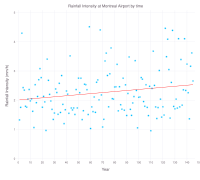

In [12]:
n = length(df_climex[:, :Year])
t = collect(1:n)

X = hcat(ones(n), df_climex[:, :Year])

# Compute the OLS solution for the coefficients (b = (X'X)^(-1) X'y)
b = X \ df_climex[:, Symbol("Maxima 24h")]  # This automatically solves the normal equation

# Extract the intercept and slope
intercept = b[1]
slope = b[2]

println(slope)

# Define the line based on the fitted model
line = x -> intercept .+ slope .* x

Gadfly.plot(
        layer(df_climex, x=t, y=line(df_climex[:, :Year]), Geom.line, Theme(default_color="red")),
        layer(df_climex, x=t, y=string("Maxima 24h"), Geom.point),
        Coord.cartesian(xmin=0, xmax=145), Guide.xticks(ticks=0:10:150),
        Guide.ylabel("Rainfall Intensity (mm/h)"),
        Guide.xlabel("Year"),
        Guide.title(string("Rainfall Intensity at Montreal Airport by time")))

0.0006118034739008446


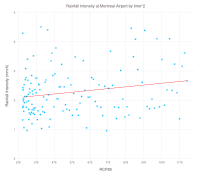

In [13]:
X = hcat(ones(n), rcp_data[:, Symbol("RCP85")])

# Compute the OLS solution for the coefficients (b = (X'X)^(-1) X'y)
b = X \ df_climex[:, Symbol("Maxima 24h")]  # This automatically solves the normal equation

# Extract the intercept and slope
intercept = b[1]
slope = b[2]

println(slope)

# Define the line based on the fitted model
line = x -> intercept .+ slope .* x

Gadfly.plot(
        layer(df_climex, x=rcp_data[:, Symbol("RCP85")], y=line(rcp_data[:, Symbol("RCP85")]), Geom.line, Theme(default_color="red")),
        layer(df_climex, x=rcp_data[:, Symbol("RCP85")], y=string("Maxima 24h"), Geom.point),
        Coord.cartesian(xmin=275, xmax=1250), Guide.xticks(ticks=275:100:1250),
        Guide.ylabel("Rainfall Intensity (mm/h)"),
        Guide.xlabel("RCP85"),
        Guide.title(string("Rainfall Intensity at Montreal Airport by time^2")))

7.154554261166043e-6


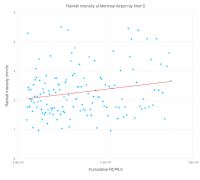

In [14]:
X = hcat(ones(n), rcp_data[:, Symbol("Cumulative RCP85")])

# Compute the OLS solution for the coefficients (b = (X'X)^(-1) X'y)
b = X \ df_climex[:, Symbol("Maxima 24h")]  # This automatically solves the normal equation

# Extract the intercept and slope
intercept = b[1]
slope = b[2]

println(slope)

# Define the line based on the fitted model
line = x -> intercept .+ slope .* x

Gadfly.plot(
        layer(df_climex, x=rcp_data[:, Symbol("Cumulative RCP85")], y=line(rcp_data[:, Symbol("Cumulative RCP85")]), Geom.line, Theme(default_color="red")),
        layer(df_climex, x=rcp_data[:, Symbol("Cumulative RCP85")], y=string("Maxima 24h"), Geom.point),
        Coord.cartesian(xmin=50000, xmax=150000),
        Guide.ylabel("Rainfall Intensity (mm/h)"),
        Guide.xlabel("Cumulative RCP8.5"),
        Guide.title(string("Rainfall Intensity at Montreal Airport by time^2")))

In [25]:
# Non-stationnaire avec variable RCP 8.5 sur mu (mu0 + mu1*RCP)

initialvalues = [23, 1, 5.0, -.01, .835, .001]
constrainedvalues = [nothing, nothing, nothing, nothing, nothing, log(delta)]

pd = GeneralScaling(
    1.0,
    [Variable("t", rcp_data[:, Symbol("RCP85")])],
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}()
)   
Σ = UncorrelatedStructure()
C = IdentityCopula

dsm = DependentScalingModel(pd, Σ, C) 
gaussian_fd = IDFCurves.fit_mle(dsm, climex_data, 1, initialvalues, constrainedvalues)
println(gaussian_fd)
println(IDFCurves.bic(gaussian_fd, climex_data))

DependentScalingModel{GeneralScaling{Real, IDFCurves.paramfun}, UncorrelatedStructure, IdentityCopula}(GeneralScaling{Real, IDFCurves.paramfun}(d₀ = 1, μ₀ = [20.0512, 0.7455], σ₀ = [6.9737], ξ = [0.0881], α = [0.7512], δ = [0.0826])
, UncorrelatedStructure())
3497.080169030692


In [24]:
# Non-stationnaire avec variable temps sur mu (mu0 + mu1*year)
pd = GeneralScaling(
    1.0,
    [Variable("t", rcp_data[:, Symbol("Year")])],
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}()
)   
Σ = UncorrelatedStructure()
C = IdentityCopula

dsm = DependentScalingModel(pd, Σ, C) 
gaussian_fd = IDFCurves.fit_mle(dsm, climex_data, 1, initialvalues, constrainedvalues)
println(gaussian_fd)
println(IDFCurves.bic(gaussian_fd, climex_data))

DependentScalingModel{GeneralScaling{Real, IDFCurves.paramfun}, UncorrelatedStructure, IdentityCopula}(GeneralScaling{Real, IDFCurves.paramfun}(d₀ = 1, μ₀ = [20.035, 0.712], σ₀ = [6.9661], ξ = [0.0903], α = [0.7511], δ = [0.0826])
, UncorrelatedStructure())
3497.5169913813734


In [17]:
# Non-stationnaire avec variable temps sur mu (mu0 + mu1*year^2)
pd = GeneralScaling(
    1.0,
    [Variable("t", rcp_data[:, Symbol("Year")] .^ 2)],
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}()
)   
Σ = UncorrelatedStructure()
C = IdentityCopula

dsm = DependentScalingModel(pd, Σ, C) 
gaussian_fd = IDFCurves.fit_mle(dsm, climex_data, 1, initialvalues, constrainedvalues)
println(gaussian_fd)
println(IDFCurves.bic(gaussian_fd, climex_data))

DependentScalingModel{GeneralScaling{Real, IDFCurves.paramfun}, UncorrelatedStructure, IdentityCopula}(GeneralScaling{Real, IDFCurves.paramfun}(d₀ = 1, μ₀ = [20.036, 0.7142], σ₀ = [6.9665], ξ = [0.0902], α = [0.7511], δ = [0.0826])
, UncorrelatedStructure())
3497.47453691903


In [18]:
# Non-stationnaire avec variable temps sur sigma (sigma0 + sigma1*Year)
initialvalues =  [24.98, 1., 1., 0.005, .835, .001]
pd = GeneralScaling(
    1.0,
    Vector{Variable}(),
    [Variable("t", rcp_data[:, Symbol("Year")])],
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}()
)   
Σ = UncorrelatedStructure()
C = IdentityCopula

dsm = DependentScalingModel(pd, Σ, C) 
gaussian_fd = IDFCurves.fit_mle(dsm, climex_data, 1, initialvalues, constrainedvalues)
println(gaussian_fd)
println(IDFCurves.bic(gaussian_fd, climex_data))

DependentScalingModel{GeneralScaling{Real, IDFCurves.paramfun}, UncorrelatedStructure, IdentityCopula}(GeneralScaling{Real, IDFCurves.paramfun}(d₀ = 1, μ₀ = [19.6862], σ₀ = [6.912, 1.1078], ξ = [0.0819], α = [0.7478], δ = [0.0826])
, UncorrelatedStructure())
3492.686645488889


In [19]:
# Non-stationnaire avec variable temps sur sigma (sigma0 + sigma1*CumulativeRCP)
initialvalues = [24.98, 1., 1., 0.005, .835, .001]
pd = GeneralScaling(
    1.0,
    Vector{Variable}(),
    [Variable("t", rcp_data[:, Symbol("RCP85")])],
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}()
)   
Σ = UncorrelatedStructure()
C = IdentityCopula

dsm = DependentScalingModel(pd, Σ, C) 
gaussian_fd = IDFCurves.fit_mle(dsm, climex_data, 1, initialvalues, constrainedvalues)
println(gaussian_fd)
println(IDFCurves.bic(gaussian_fd, climex_data))

DependentScalingModel{GeneralScaling{Real, IDFCurves.paramfun}, UncorrelatedStructure, IdentityCopula}(GeneralScaling{Real, IDFCurves.paramfun}(d₀ = 1, μ₀ = [19.6778], σ₀ = [6.9373, 1.1508], ξ = [0.0658], α = [0.7483], δ = [0.0826])
, UncorrelatedStructure())
3484.962204327468


In [20]:
# Non-stationnaire avec variable temps sur alpha (alpha0 + alpha1*RCP)
initialvalues = [24.98, 1, 0.005, .84, 0.5, .001]
pd = GeneralScaling(
    1.0,
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}(),
    [Variable("t", rcp_data[:, Symbol("RCP85")])],
    Vector{Variable}()
)   
Σ = UncorrelatedStructure()
C = IdentityCopula

dsm = DependentScalingModel(pd, Σ, C) 
gaussian_fd = IDFCurves.fit_mle(dsm, climex_data, 1, initialvalues, constrainedvalues)
println(gaussian_fd)
println(IDFCurves.bic(gaussian_fd, climex_data))

DependentScalingModel{GeneralScaling{Real, IDFCurves.paramfun}, UncorrelatedStructure, IdentityCopula}(GeneralScaling{Real, IDFCurves.paramfun}(d₀ = 1, μ₀ = [20.014], σ₀ = [6.9634], ξ = [0.0814], α = [0.751, 0.4643], δ = [0.0826])
, UncorrelatedStructure())
3491.2945034308173


725×2 DataFrame
 Row │ Model         Empirical   
     │ Float64       Float64     
─────┼───────────────────────────
   1 │ -1.88518      -1.89949
   2 │ -1.774        -1.67482
   3 │ -1.70273      -1.65888
   4 │ -1.6489       -1.64329
   5 │ -1.60505      -1.62846
   6 │ -1.56774      -1.61702
   7 │ -1.53507      -1.60733
   8 │ -1.50588      -1.56781
   9 │ -1.4794       -1.51259
  10 │ -1.45511      -1.51022
  11 │ -1.43262      -1.47586
  12 │ -1.41163      -1.4667
  13 │ -1.39193      -1.4145
  14 │ -1.37333      -1.41293
  15 │ -1.35571      -1.40583
  16 │ -1.33893      -1.39031
  17 │ -1.32291      -1.34536
  18 │ -1.30757      -1.34244
  19 │ -1.29284      -1.3222
  20 │ -1.27866      -1.30929
  21 │ -1.26498      -1.30472
  22 │ -1.25176      -1.30307
  23 │ -1.23897      -1.29309
  24 │ -1.22656      -1.28864
  25 │ -1.21452      -1.26439
  26 │ -1.20281      -1.25958
  27 │ -1.19141      -1.22153
  28 │ -1.1803       -1.19222
  29 │ -1.16946      -1.16731
  30 │ -1.15888

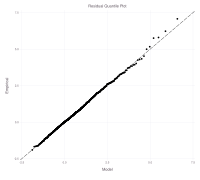

In [30]:
# Non-stationnaire avec variable temps sur mu (mu0 + mu1*year^2)
initialvalues = [23, 1, 5.0, -.01, .835, .001]
pd = GeneralScaling(
    1.0,
    [Variable("t", rcp_data[:, Symbol("Year")])],
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}()
)   
Σ = UncorrelatedStructure()
C = IdentityCopula

dsm = DependentScalingModel(pd, Σ, C) 
gaussian_fd = IDFCurves.fit_mle(dsm, climex_data, 1, initialvalues, constrainedvalues)

## Fixer pour une annee precise? et tenter de le faire pour toutes les durees.
p1_24h = IDFCurves.qqplot_std_data(gaussian_fd, climex_data, [1,2,6,12,24])

DependentScalingModel{GeneralScaling{Real, IDFCurves.paramfun}, UncorrelatedStructure, IdentityCopula}(GeneralScaling{Real, IDFCurves.paramfun}(d₀ = 1, μ₀ = [19.6778], σ₀ = [6.9373, 1.1508], ξ = [0.0658], α = [0.7483], δ = [0.0826])
, UncorrelatedStructure())
725×2 DataFrame
 Row │ Model         Empirical   
     │ Float64       Float64     
─────┼───────────────────────────
   1 │ -1.88518      -1.79837
   2 │ -1.774        -1.7085
   3 │ -1.70273      -1.70202
   4 │ -1.6489       -1.56239
   5 │ -1.60505      -1.53315
   6 │ -1.56774      -1.51167
   7 │ -1.53507      -1.497
   8 │ -1.50588      -1.48047
   9 │ -1.4794       -1.47755
  10 │ -1.45511      -1.44756
  11 │ -1.43262      -1.42519
  12 │ -1.41163      -1.42361
  13 │ -1.39193      -1.40497
  14 │ -1.37333      -1.3985
  15 │ -1.35571      -1.3862
  16 │ -1.33893      -1.35081
  17 │ -1.32291      -1.34845
  18 │ -1.30757      -1.34324
  19 │ -1.29284      -1.34179
  20 │ -1.27866      -1.32654
  21 │ -1.26498      -1.304

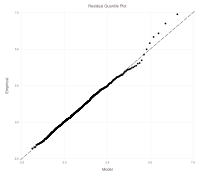

In [22]:
# Non-stationnaire avec variable temps sur sigmea (sigma0 + sigma1*RCP8.52)
initialvalues = [24.98, 1., 1., -0.005, .835, .001]
pd = GeneralScaling(
    1.0,
    Vector{Variable}(),
    [Variable("t", rcp_data[:, Symbol("RCP85")])],
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}()
)   
Σ = UncorrelatedStructure()
C = IdentityCopula

dsm = DependentScalingModel(pd, Σ, C) 
gaussian_fd = IDFCurves.fit_mle(dsm, climex_data, 1, initialvalues, constrainedvalues)
println(gaussian_fd)

## Fixer pour une annee precise? et tenter de le faire pour toutes les durees.
p1_24h = IDFCurves.qqplot_std_data(gaussian_fd, climex_data, [1,2,6,12,24])

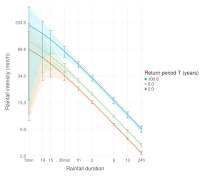

┌ Warning: The following aesthetics are mapped, but not used by any geometry:
│ shape
└ @ Gadfly C:\Users\CM\.julia\packages\Gadfly\OQ068\src\Gadfly.jl:503
┌ Warning: The following aesthetics are mapped, but not used by any geometry:
│ shape
└ @ Gadfly C:\Users\CM\.julia\packages\Gadfly\OQ068\src\Gadfly.jl:503


In [23]:
set_default_plot_size(20cm, 18cm)
plotIDFCurves(gaussian_fd, climex_data, show_confidence_intervals=true, ribbon=true, dgev_return_levels=true, T_values=[2,5,100], year=1)

Prochaines étapes: 
Tenter d'intégrer la modélisation par copule gaussienne à la dGEV non-stationnaire pour tenir compte de l'inter-dépendence entre les durées et mieux modéliser les incertitudes pour les périodes de retour. 

1. post-traitement apres avoir trouvé le modèle. post-traitement avec la dGEV (hist vs simulée). on va le faire seulement sur les maxima annuels. dans le but de corriger seulement le meilleur modele et donc de bonifier les IDF
3. analyse explo des variables explicatives (pluie en fct de temps, RCP, etc.)